In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [1]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy
import matplotlib
import scipy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.colors as mcolors

from datetime import datetime, timedelta
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import netCDF4
import string

import numpy as np
import xarray as xr
from datetime import timedelta
import gsw
import ArcTools as Atools
import pandas as pd

# PSAL

In [2]:
# ds_anom = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_4/psal_anomalies_relative_ISAS_barents_full.nc',decode_times=False)



# boxes = pd.read_csv('/home/aprigent/Documents/Projects/Analysis_obs/Arctic_design_10m_150_test_new.csv')



# xc150 = np.array(([boxes["Longitude 1"].values,boxes["Longitude 2"].values,
#                    boxes["Longitude 2"].values,boxes["Longitude 1"].values,boxes["Longitude 1"].values])).T
# yc150 = np.array(([boxes["Latitude 1"].values,boxes["Latitude 1"].values,
#                    boxes["Latitude 2"].values,boxes["Latitude 2"].values,boxes["Latitude 1"].values])).T
# box_id = np.array(boxes["Box ID"].values)


# from matplotlib.path import Path
# import numpy as np

# profiles_in_box = {}

# for i in range(len(xc150)):

#     # build polygon for the box
#     polygon = np.column_stack((xc150[i], yc150[i]))
#     path = Path(polygon)

#     # combine profile coordinates
#     points = np.column_stack((ds_anom.longitude.values, ds_anom.latitude.values))

#     # test which profiles fall inside
#     inside = path.contains_points(points)

#     # store indices of profiles inside the box
#     profiles_in_box[box_id[i]] = np.where(inside)[0]
#     if len(profiles_in_box[box_id[i]])>0:
#         print(f"Box {box_id[i]}: {len(profiles_in_box[box_id[i]])} profiles inside")
# counts = [len(profiles_in_box[box_id[i]]) for i in range(len(box_id))]
# import numpy as np

# nbox = len(box_id)
# ndepth = ds_anom.depth.size
# nprof = ds_anom.profile.size   # or however profiles are indexed

# slope_box_depth = np.full((nbox, ndepth), np.nan)
# pval_box_depth = np.full((nbox, ndepth), np.nan)

# temp_anom_detrended = np.full(
#     ds_anom.salinity_QC_anom.shape,
#     np.nan
# )

# temp_anom_array = np.array(ds_anom.salinity_QC_anom)
# time_array = np.array(ds_anom.time)

# from scipy.stats import linregress

# # Loop over spatial boxes
# for i in range(nbox):

#     box_num = box_id[i]  # Current box identifier
#     print(box_num)

#     # Indices of profiles that fall inside this box
#     prof_idx = profiles_in_box[box_num]

#     # Skip box if too few profiles
#     if len(prof_idx) < 3:
#         #print('Box number: ',box_num,' has been skipped, too few profiles')
#         continue

#     # Extract time values for profiles in this box
#     time = time_array[prof_idx]

#     # Convert time from days to years
#     t = time / 365.25

#     # Loop over depth levels
#     for j in range(ndepth):

#         # Temperature anomaly at this depth for selected profiles
#         temp_anom = temp_anom_array[prof_idx, j]

#         # Mask valid (finite) values
#         mask = np.isfinite(temp_anom)

#         # Proceed only if enough valid data points for regression
#         if np.sum(mask) > 4:

#             # Perform linear regression: temp_anom = slope * t + intercept
#             slope, intercept, rvalue, pvalue, _ = linregress(t[mask], temp_anom[mask])

#             # Store slope and p-value for this box and depth
#             slope_box_depth[i, j] = slope
#             pval_box_depth[i, j] = pvalue

#             # Compute fitted linear trend over time
#             trend = slope * t + intercept

#             # Detrend only if trend is statistically significant (p < 0.05)
#             if pvalue < 0.05:
#                 temp_anom_detrended[prof_idx, j] = temp_anom - trend
#             else:
#                 # Keep original data if trend is not significant
#                 temp_anom_detrended[prof_idx, j] = temp_anom

#         else:
#             # Not enough valid data → keep original values
#             temp_anom_detrended[prof_idx, j] = temp_anom
            
# ds_anom["salinity_QC_anom_dtd"] = (['profile','depth'],temp_anom_detrended)
# ds_anom.to_netcdf('/data0/user/aprigent/PROCESSED/level_5/psal_anomalies_detrended_relative_ISAS_barents_full.nc')

# Load boxes

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
from matplotlib.path import Path
from scipy.stats import linregress
import gc


def detrend_psal_anomalies_per_basin(
    input_file,
    box_file,
    output_file,
    anomaly_var="salinity_QC_anom",
    detrended_var="salinity_QC_anom_dtd",
    p_threshold=0.05,
):
    """
    Detrend salinity anomalies inside spatial boxes.

    Parameters
    ----------
    input_file : str
        Path to anomaly NetCDF file.
    box_file : str
        CSV file containing spatial box definitions.
    output_file : str
        Output NetCDF filename.
    anomaly_var : str
        Name of anomaly variable.
    detrended_var : str
        Name of detrended anomaly variable.
    p_threshold : float
        Significance threshold for detrending.
    """

    print(f"\nProcessing: {input_file}")

    # --------------------------------------------------
    # Load data
    # --------------------------------------------------
    ds_anom = xr.open_dataset(input_file, decode_times=False)

    boxes = pd.read_csv(box_file)

    # --------------------------------------------------
    # Build polygons
    # --------------------------------------------------
    xc = np.array([
        boxes["Longitude 1"].values,
        boxes["Longitude 2"].values,
        boxes["Longitude 2"].values,
        boxes["Longitude 1"].values,
        boxes["Longitude 1"].values
    ]).T

    yc = np.array([
        boxes["Latitude 1"].values,
        boxes["Latitude 1"].values,
        boxes["Latitude 2"].values,
        boxes["Latitude 2"].values,
        boxes["Latitude 1"].values
    ]).T

    box_id = np.array(boxes["Box ID"].values)

    # --------------------------------------------------
    # Find profiles inside each box
    # --------------------------------------------------
    profiles_in_box = {}

    points = np.column_stack((
        ds_anom.longitude.values,
        ds_anom.latitude.values
    ))

    for i in range(len(xc)):
        

        polygon = np.column_stack((xc[i], yc[i]))
        path = Path(polygon)

        inside = path.contains_points(points)

        profiles_in_box[box_id[i]] = np.where(inside)[0]

        nprof_box = len(profiles_in_box[box_id[i]])

        if nprof_box > 0:
            print(f"Box {box_id[i]}: {nprof_box} profiles inside")

    # --------------------------------------------------
    # Prepare arrays
    # --------------------------------------------------
    nbox = len(box_id)
    ndepth = ds_anom.depth.size

    slope_box_depth = np.full((nbox, ndepth), np.nan)
    pval_box_depth = np.full((nbox, ndepth), np.nan)

    temp_anom_detrended = np.full(
        ds_anom[anomaly_var].shape,
        np.nan
    )

    temp_anom_array = np.array(ds_anom[anomaly_var])
    time_array = np.array(ds_anom.time)

    # --------------------------------------------------
    # Detrending loop
    # --------------------------------------------------
    for i in range(nbox):

        
        current_box = box_id[i]
        prof_idx = profiles_in_box[current_box]

        # Skip if too few profiles
        if len(prof_idx) < 4:
            temp_anom_detrended[prof_idx,:] = temp_anom_array[prof_idx,:]
            continue
        
        print(f"Detrending box: {current_box}")
        time = time_array[prof_idx]

        
        t = time

        for j in range(ndepth):

            temp_anom = temp_anom_array[prof_idx, j]

            mask = np.isfinite(temp_anom)

            if (np.sum(mask) > 4) and ((np.max(t[mask]) -np.min(t[mask]))/365.25>5): # at least 5 years

                slope, intercept, rvalue, pvalue, _ = linregress(
                    t[mask],
                    temp_anom[mask]
                )

                slope_box_depth[i, j] = slope
                pval_box_depth[i, j] = pvalue

                trend = slope * t + intercept

                # Remove trend only if significant
                if pvalue < p_threshold:
                    temp_anom_detrended[prof_idx, j] = (
                        temp_anom - trend
                    )
                else:
                    temp_anom_detrended[prof_idx, j] = temp_anom

            else:
                temp_anom_detrended[prof_idx, j] = temp_anom

    # --------------------------------------------------
    # Save detrended field
    # --------------------------------------------------
    ds_anom[detrended_var] = (
        ["profile", "depth"],
        temp_anom_detrended
    )

#     # Optional: save regression diagnostics
#     ds_anom["trend_slope"] = (
#         ["box", "depth"],
#         slope_box_depth
#     )

#     ds_anom["trend_pvalue"] = (
#         ["box", "depth"],
#         pval_box_depth
#     )

#     ds_anom["box"] = box_id

    ds_anom.to_netcdf(output_file)

    print(f"Saved: {output_file}")

  



In [4]:

box_file = (
    "/home/aprigent/Documents/Projects/Analysis_obs/"
    "Arctic_design_10m_150_test_new.csv"
)


basins = [
    "barents",
    "eurasian",
    "amerasian",
    "nordic",
    "amerasian_shelf",
    "siberian_shelf",
    "baffin",
    "kara"
]

for basin in basins:

    input_file = (
        f"/data0/user/aprigent/PROCESSED/level_4/"
        f"psal_anomalies_relative_ISAS_{basin}_full_after_2005.nc"
    )

    output_file = (
        f"/data0/user/aprigent/PROCESSED/level_5/"
        f"psal_anomalies_detrended_relative_ISAS_{basin}_full_after_2005.nc"
    )

    detrend_psal_anomalies_per_basin(
        input_file=input_file,
        box_file=box_file,
        output_file=output_file,
        anomaly_var="salinity_QC_anom",
        detrended_var="salinity_QC_anom_dtd",
        p_threshold=0.05,
    )


Processing: /data0/user/aprigent/PROCESSED/level_4/psal_anomalies_relative_ISAS_barents_full_after_2005.nc
Box 90: 1 profiles inside
Box 91: 3 profiles inside
Box 92: 1 profiles inside
Box 131: 73 profiles inside
Box 132: 499 profiles inside
Box 133: 4565 profiles inside
Box 134: 1741 profiles inside
Box 136: 7 profiles inside
Box 137: 7 profiles inside
Box 138: 4 profiles inside
Box 183: 74 profiles inside
Box 184: 1912 profiles inside
Box 185: 3303 profiles inside
Box 186: 1811 profiles inside
Box 187: 746 profiles inside
Box 188: 1123 profiles inside
Box 189: 289 profiles inside
Box 190: 214 profiles inside
Box 191: 100 profiles inside
Box 192: 35 profiles inside
Box 193: 7 profiles inside
Box 242: 759 profiles inside
Box 243: 3410 profiles inside
Box 244: 1157 profiles inside
Box 245: 934 profiles inside
Box 246: 1613 profiles inside
Box 247: 428 profiles inside
Box 248: 115 profiles inside
Box 249: 108 profiles inside
Box 250: 34 profiles inside
Box 298: 740 profiles inside
Box 2

# checking

In [7]:
ds_test = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_4/psal_anomalies_relative_ISAS_barents_full_after_2005.nc')
ds_test

<xarray.Dataset>
Dimensions:           (profile: 39908, depth: 187)
Coordinates:
  * profile           (profile) int64 4619 4625 4628 ... 310545 310546 310547
  * depth             (depth) float64 1.0 3.0 5.0 ... 5.3e+03 5.4e+03 5.5e+03
    lon               (profile) float64 ...
    lat               (profile) float64 ...
Data variables: (12/14)
    longitude         (profile) float64 ...
    latitude          (profile) float64 ...
    time              (profile) datetime64[ns] ...
    source            (profile) object ...
    dataset_index     (profile) float64 ...
    is_duplicate      (profile) float64 ...
    ...                ...
    sum_depth         (profile) float64 ...
    nb_depth          (profile) float64 ...
    prof_descr        (profile) |S30 ...
    salinity_QC       (profile, depth) float64 ...
    salinity_QC_anom  (profile, depth) float64 ...
    salinity_clim     (profile, depth) float64 ...
Attributes:
    title:        ARGO salinity profiles
    source:       ARGO
    featureType:  profile
    Comments:     ARGO temperature profiles interpolated on ISAS vertical lev...

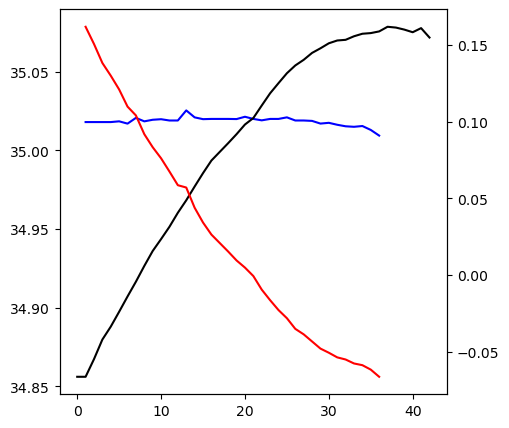

In [16]:
f,ax = plt.subplots(1,1,figsize=[5,5])
id_prof = 1006
ax.plot(ds_test.salinity_QC[id_prof,:],color='blue')
ax.plot(ds_test.salinity_clim[id_prof,:],color='black')
ax1 = ax.twinx()
ax1.plot(ds_test.salinity_QC_anom[id_prof,:],color='red')

In [18]:
ds_test.time[id_prof].values

numpy.datetime64('2021-05-03T00:00:00.000000000')